[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laboratoire-de-Chemoinformatique/SynPlanner/blob/main/tutorials/16_Building_block_search.ipynb)

In [ ]:
# Colab setup — this cell does nothing when you run the notebook locally.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.run(
        [
            "pip",
            "install",
            "-q",
            "git+https://github.com/Laboratoire-de-Chemoinformatique/SynPlanner.git@main",
        ],
        check=True,
    )
    print("SynPlanner installed. If an import below fails, restart the runtime.")


In [1]:
from pathlib import Path

from synplan.utils.loading import download_preset

# Download preset data (or use already downloaded)
paths = download_preset("synplanner-gps", save_to="synplan_data")

# input data
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]

# output folder (shared with other tutorials)
results_folder = Path("tutorial_results").resolve()
results_folder.mkdir(exist_ok=True)

## 2. Retrosynthetic planning
Run a short example to produce routes, or skip if you already have `routes_*.json/csv`.

In [2]:
from synplan.chem.utils import mol_from_smiles

example_smiles = "N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1"

target_molecule = mol_from_smiles(
    example_smiles,
    clean2d=True,
    standardize=True,
    clean_stereo=True
    )

In [3]:
target_molecule

## Run example planning

In [4]:
from synplan.mcts.tree import Tree
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

building_blocks = load_building_blocks(building_blocks_path, standardize=False)
reaction_rules = load_reaction_rules(reaction_rules_path)

policy_network = load_policy_function(weights_path=ranking_policy_network)

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_network,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
    normalize=True,
)
evaluation_function = load_evaluation_function(eval_config)

tree = Tree(
    target=target_molecule,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_network,
    evaluation_function=evaluation_function,
).run()

tree

  0%|          | 0/300 [00:00<?, ?it/s]

Tree for: C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
Time: 7.6 seconds
Number of nodes: 3919
Number of iterations: 300
Number of visited nodes: 293
Number of found routes: 905

In [5]:
from IPython.display import display

from synplan.chem.reaction.routes import Route
from synplan.chem.reaction.routes.analysis import (
    collect_bb_usage_stats,
    route_ids_with_exact_bb,
)
from synplan.chem.reaction.routes.notebook_plots import (
    plot_top_real_bbs,
    plot_top_real_bbs_with_chython_svg,
)
from synplan.chem.reaction.routes.representation import compose_all_route_cgrs


## RouteCGR Composition

`compose_all_route_cgrs` converts each route into one RouteCGR object. Use `preserve_transient_bonds=True` when comparing routes, because bonds that form and later break during the route are part of the route history and participate in the RouteCGR hash.


In [6]:
all_route_cgrs = compose_all_route_cgrs(tree)

## Exact Building-Block Route Lookup

`route_ids_with_exact_bb` checks exact pseudo-reactant identity in decomposed RouteCGRs. Use `kind="real"` for BBs whose atoms survive into the target molecule, `kind="supporting"` for PG/FGI/support fragments, and `kind="any"` for either.


In [7]:
bb_mol_smi = 'c1cnccc1CN'
display(mol_from_smiles(bb_mol_smi))

In [8]:
route_ids = route_ids_with_exact_bb(bb_mol_smi, all_route_cgrs)
print('Number of routes containing the slected BB:', len(route_ids))

Number of routes containing the slected BB: 546


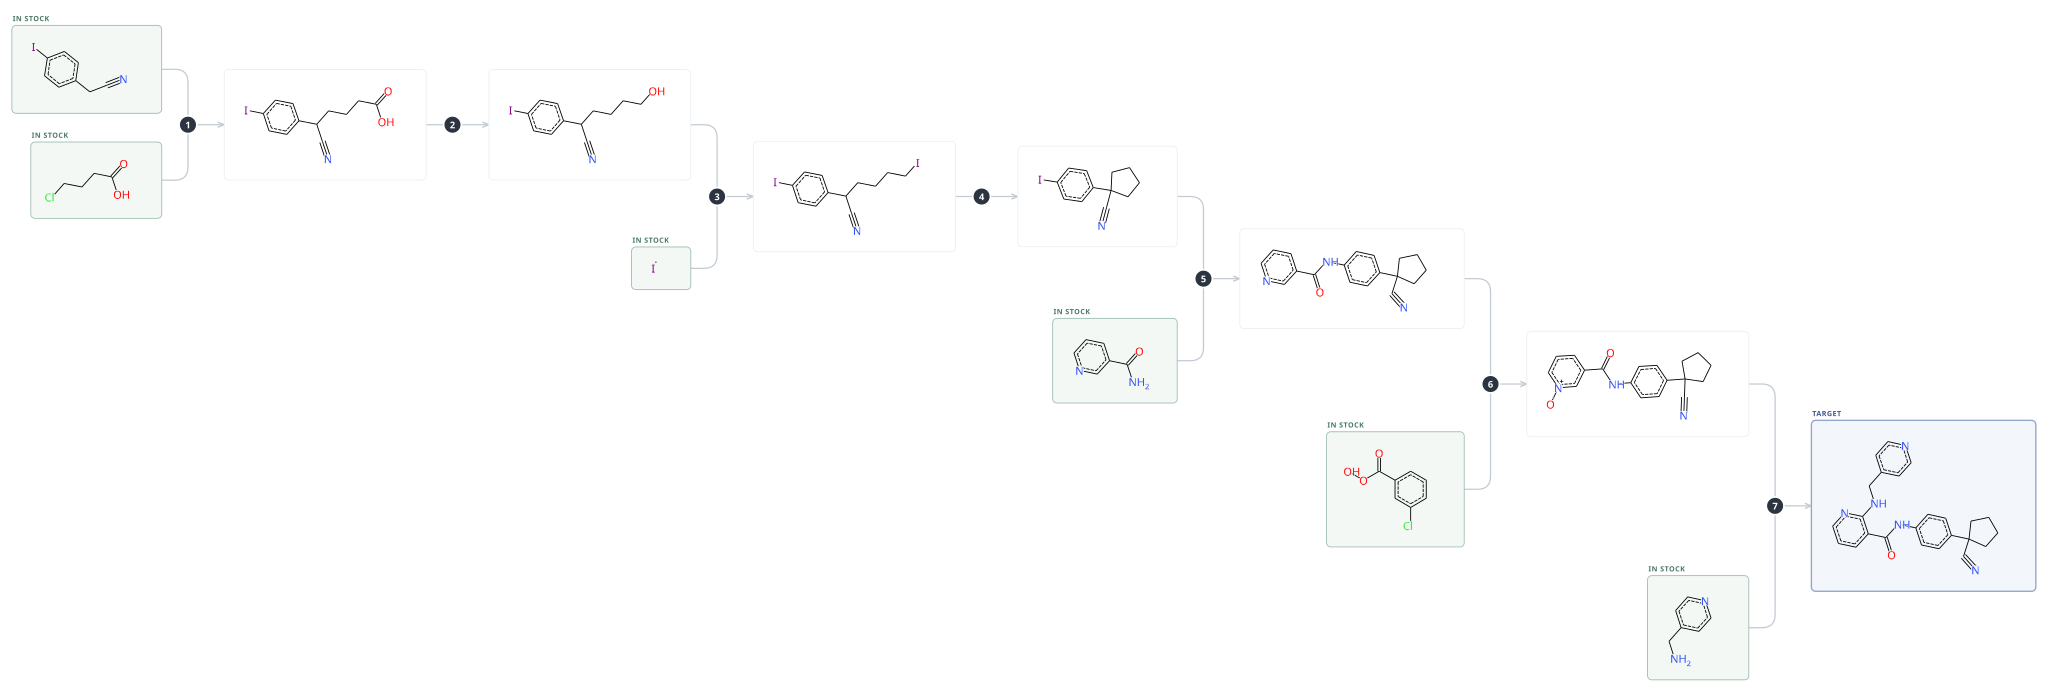

In [9]:
display(Route.from_tree(tree, route_ids[-1]))

## Building-Block Usage Statistics

`collect_bb_usage_stats` decomposes each RouteCGR once and separates real BBs from supporting fragments by atom overlap with the target product projection.


In [10]:
bb_stats_1 = collect_bb_usage_stats(all_route_cgrs)

In [11]:
display(bb_stats_1["real_bb"])       # atoms contribute to target molecule

{'c1cc(ccc1C2(CCCC2)C#N)N': {'occurrences': 582,
  'route_count': 582,
  'route_ids': [33,
   41,
   42,
   56,
   57,
   58,
   59,
   60,
   61,
   63,
   64,
   66,
   68,
   69,
   70,
   71,
   72,
   73,
   91,
   98,
   125,
   132,
   133,
   134,
   135,
   136,
   140,
   142,
   143,
   144,
   145,
   147,
   148,
   149,
   150,
   151,
   152,
   153,
   154,
   155,
   156,
   157,
   158,
   159,
   160,
   161,
   162,
   163,
   165,
   167,
   168,
   169,
   170,
   171,
   172,
   174,
   175,
   176,
   177,
   179,
   183,
   203,
   204,
   210,
   218,
   220,
   229,
   246,
   257,
   282,
   283,
   284,
   285,
   286,
   288,
   290,
   295,
   299,
   303,
   304,
   310,
   311,
   312,
   314,
   315,
   317,
   320,
   321,
   322,
   325,
   326,
   328,
   329,
   330,
   336,
   337,
   339,
   345,
   346,
   347,
   348,
   349,
   351,
   353,
   358,
   360,
   369,
   376,
   377,
   378,
   392,
   396,
   397,
   403,
   411,
   423,
   436,


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Top 10 BBs, min_mol_size=4'}, ylabel='Route count'>)

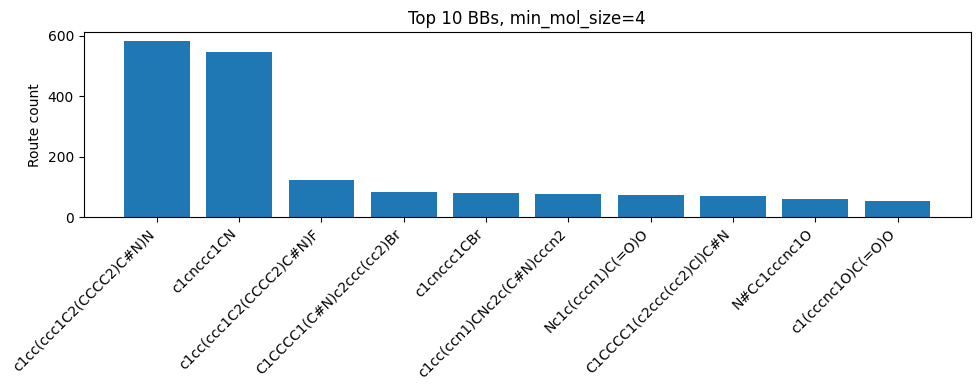

In [12]:
plot_top_real_bbs(bb_stats_1["real_bb"], top_n=10, min_mol_size=4)

In [13]:
plot_top_real_bbs_with_chython_svg(
    bb_stats_1["real_bb"],
    top_n=10,
    min_mol_size=4,
)


'\n<style>\n  .bb-plot {\n    display:flex;\n    align-items:flex-end;\n    gap:18px;\n    min-height:430px;\n    padding:8px 4px;\n  }\n  .bb-col {\n    width:135px;\n    text-align:center;\n    font-family:Arial, sans-serif;\n  }\n  .bb-count { font-size:13px; margin-bottom:4px; }\n  .bb-bar-wrap {\n    height:190px;\n    display:flex;\n    align-items:flex-end;\n    justify-content:center;\n  }\n  .bb-bar {\n    width:42px;\n    background:#4c78a8;\n    border-radius:3px 3px 0 0;\n  }\n  .bb-mol {\n    min-height:130px;\n    display:flex;\n    align-items:center;\n    justify-content:center;\n    overflow:visible;\n  }\n  .bb-mol svg {\n    max-width:130px !important;\n    max-height:120px !important;\n    width:auto !important;\n    height:auto !important;\n    overflow:visible !important;\n  }\n  .bb-smi {\n    font-size:10px;\n    line-height:1.15;\n    word-break:break-all;\n    min-height:42px;\n  }\n</style>\n<div class="bb-plot">\n\n  <div class="bb-col">\n    <div class="bb-

In [14]:
plot_top_real_bbs_with_chython_svg(bb_stats_1["supporting"], top_n=10, min_mol_size=4)

'\n<style>\n  .bb-plot {\n    display:flex;\n    align-items:flex-end;\n    gap:18px;\n    min-height:430px;\n    padding:8px 4px;\n  }\n  .bb-col {\n    width:135px;\n    text-align:center;\n    font-family:Arial, sans-serif;\n  }\n  .bb-count { font-size:13px; margin-bottom:4px; }\n  .bb-bar-wrap {\n    height:190px;\n    display:flex;\n    align-items:flex-end;\n    justify-content:center;\n  }\n  .bb-bar {\n    width:42px;\n    background:#4c78a8;\n    border-radius:3px 3px 0 0;\n  }\n  .bb-mol {\n    min-height:130px;\n    display:flex;\n    align-items:center;\n    justify-content:center;\n    overflow:visible;\n  }\n  .bb-mol svg {\n    max-width:130px !important;\n    max-height:120px !important;\n    width:auto !important;\n    height:auto !important;\n    overflow:visible !important;\n  }\n  .bb-smi {\n    font-size:10px;\n    line-height:1.15;\n    word-break:break-all;\n    min-height:42px;\n  }\n</style>\n<div class="bb-plot">\n\n  <div class="bb-col">\n    <div class="bb-